In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from src.union_find import uf_cluster_growth
from src.uf_visualization import visualize_uf_run
from src.create_graph import Create_Dummy_Surface_code_graph

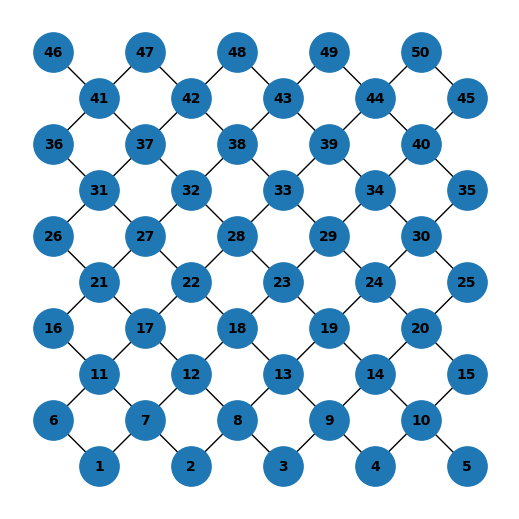

In [2]:
# Example graph

data = Create_Dummy_Surface_code_graph(5)
G = nx.Graph()
G.add_nodes_from(data["All_nodes"])
G.add_edges_from(data["edges"])
pos = data['coord_by_det']
# draw graph
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=10,
    font_weight="bold"
)

plt.axis("equal")
plt.show()

Edge with weight 10:  (46, 51, 10)


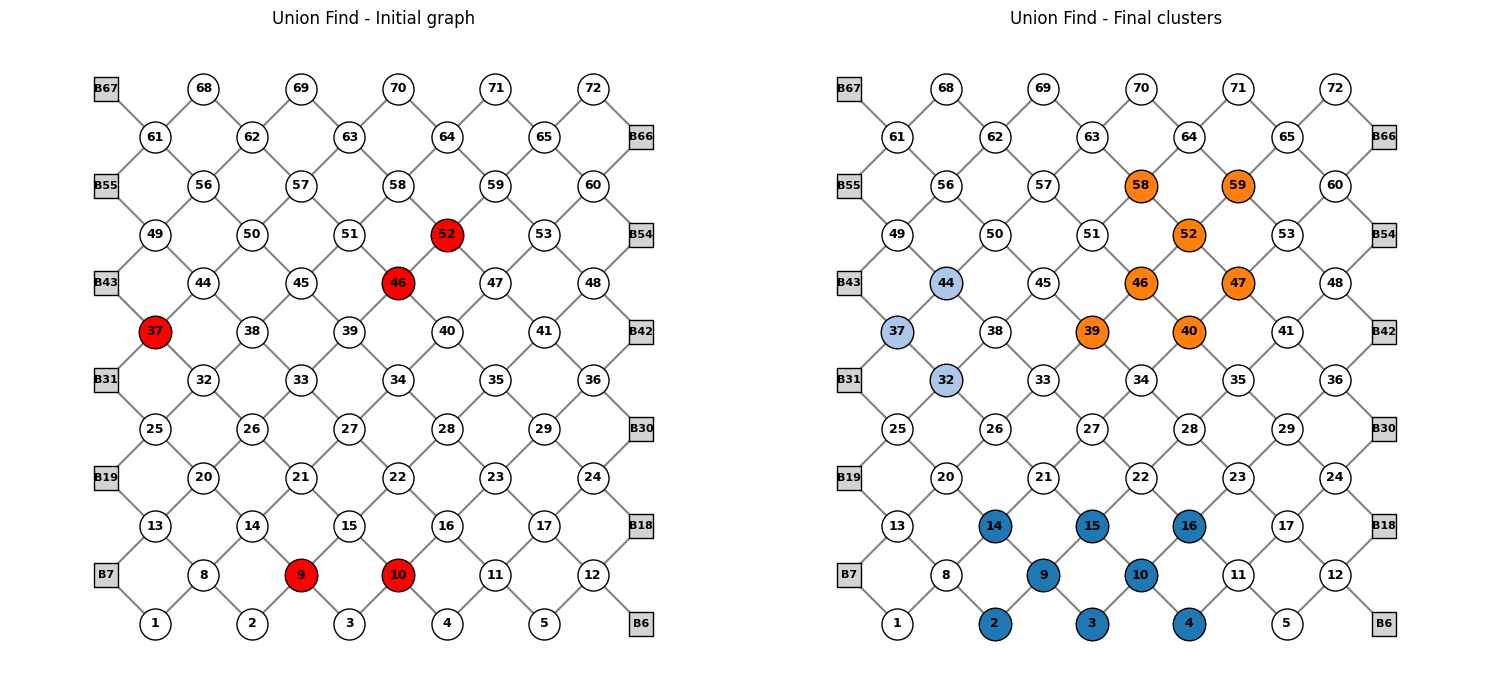

In [3]:
data = Create_Dummy_Surface_code_graph(6)

dets, Edges, boundary_nodes = data['detector_nodes'], data['edges'], data['boundary_nodes']

edges = [(u, v,10) if u == 46 and v != 52 else (u,v,1) for (u, v) in Edges]

defects = [10,9,37, 46,52]

for (u, v, w) in edges:
    if w == 10:
        print(f"Edge with weight 10:  {(u, v, w)}" )

# UF Decoding
clusters, parity, touches_boundary = uf_cluster_growth(dets, edges, defects, boundary_nodes)

# visualize
visualize_uf_run(
    uf_graph=data,
    defects=defects,
    clusters=clusters
)

Edge with weight 10:  (51, 57, 10)
Edge with weight 10:  (46, 51, 10)
Edge with weight 10:  (51, 58, 10)
Edge with weight 10:  (45, 51, 10)


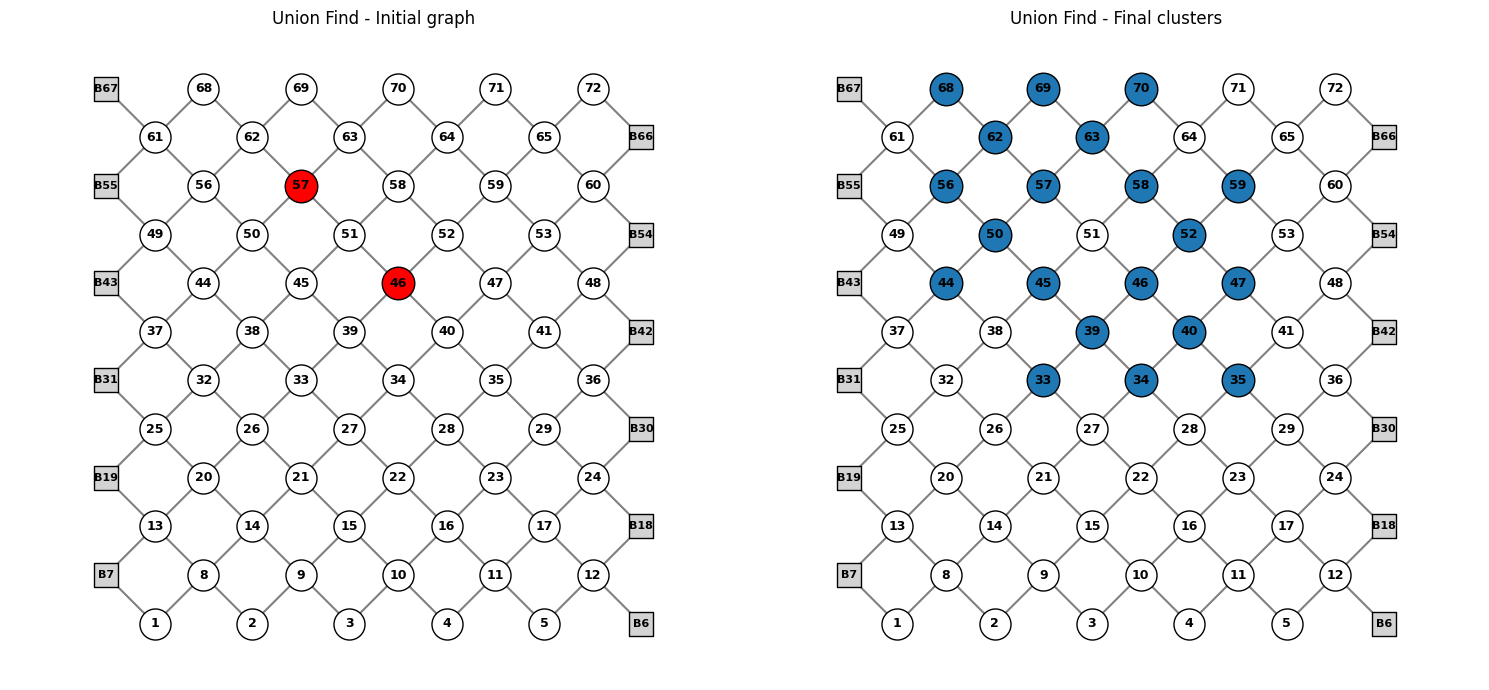

In [4]:
data = Create_Dummy_Surface_code_graph(6)

dets, Edges, boundary_nodes = data['detector_nodes'], data['edges'], data['boundary_nodes']

edges = [(u, v,10) if u == 51 or v == 51 else (u,v,1) for (u, v) in Edges]

defects = [46, 57]
for (u, v, w) in edges:
    if w == 10:
        print(f"Edge with weight 10:  {(u, v, w)}" )

# UF Decoding
clusters, parity, touches_boundary = uf_cluster_growth(dets, edges, defects, boundary_nodes)

# visualize
visualize_uf_run(
    uf_graph=data,
    defects=defects,
    clusters=clusters
)

### It can be observed that - 
#### 1. All defects (odd clusters) are growing 
#### 2. Odd Clusters stop growing when it touches boundary node 
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     - cluster 37 in output image of cell 3
#### 3. Even Clusters do not grow
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     - merged cluster 9, 10 in output image of cell 3
#### 4. Edges connect only when they are fully grown 
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     - cluster 46 do not connect to 51 in output image of cell 3 and
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     - no the final cluster skips node 51, as all edges connecting node 51 are of weight 10 in output image of cell 4